The following code helps you to load and visualize the data (skeleton) in 3D xyz coordinates.
 

In [1]:
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
plt.style.use('seaborn-v0_8-poster')

#filename and folder to plot
fname= "jumping_5"
folder =  r"C:\Users\bluek\Downloads\drive-download-20260128T185252Z-3-001"

location_name=os.path.join(folder,fname+".npy")
vals = np.load(location_name)
xyz = np.reshape( vals[:,:], (38,3,-1) )


print(xyz.shape)

#define the root joint and scaling of the values
r = 1000
xroot, yroot, zroot = xyz[0,0,0], xyz[0,0,1], xyz[0,0,2]

#define the connections between the joints (skeleton) 
I = np.array(
        [1, 2, 3, 4, 5, 6, 1, 8, 9, 10, 11, 12, 1, 14, 15, 16, 17, 18, 19, 16, 21, 22, 23, 25, 26, 24, 28, 16, 30, 31,
         32, 33, 34, 35, 33, 37]) - 1
J = np.array(
        [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32,
         33, 34, 35, 36, 37, 38]) - 1


(38, 3, 100)


In [2]:
# plot the skeleton accroding to joints (each plot is png image in anim folder)
os.makedirs("anim", exist_ok=True)
for tind in range(1,xyz.shape[2]):
    
    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    for ijind in range(0,I.shape[0]):
        xline = np.array([xyz[I[ijind],0,tind], xyz[J[ijind],0,tind]])
        yline = np.array([xyz[I[ijind],1,tind], xyz[J[ijind],1,tind]])
        zline = np.array([xyz[I[ijind],2,tind], xyz[J[ijind],2,tind]])
        # use plot if you'd like to plot skeleton with lines
        ax.plot(xline,yline,zline)
    
    # use scatter if you'd like to plot all points without lines 
    # ax.scatter(xyz[:,0,tind],xyz[:,1,tind],xyz[:,2,tind], c = 'r', s = 50)   

    ax.set_xlim([-r+xroot, r+xroot])
    ax.set_zlim([-r+zroot, r+zroot])
    ax.set_ylim([-r+yroot, r+yroot])
    
    plt.savefig('anim/'+f"{tind}.png")
    plt.close()

# when plotting a single sample (the skeleton can simply be plotted without saving an image)
#     plt.draw()
#     plt.pause(.001)
#     plt.show()

 
    
# save the animated plot as a gif in anim folder 
from PIL import Image

images = [Image.open('anim/'+f"{n}.png") for n in range(1,xyz.shape[2])]
images[0].save('anim/'+fname+'.gif', save_all=True, append_images=images[1:], duration=30, loop=0) 

# remove ploted png images
for n in range(1,xyz.shape[2]):
    os.remove('anim/'+f"{n}.png")





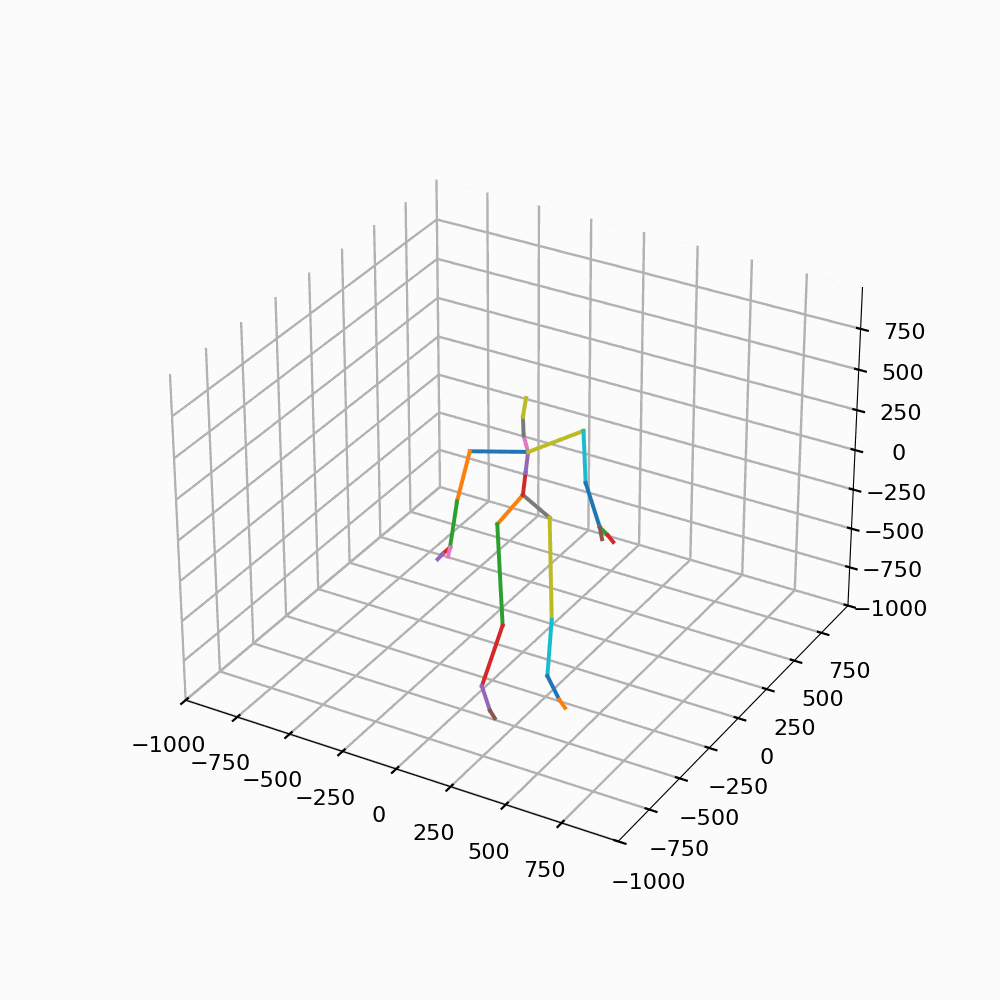

In [7]:
from IPython.display import Image as IPImage, display

display(IPImage(filename='anim/' + fname + '.gif'))

Modes for 70%: 2
Modes for 80%: 3
Modes for 90%: 5
Modes for 95%: 7


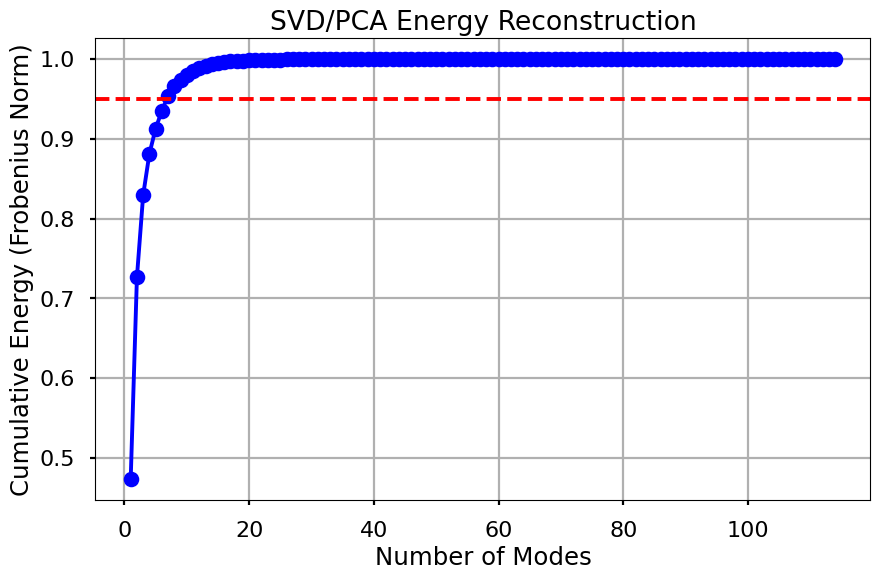

In [3]:

all_files = [f for f in os.listdir(folder) if f.endswith('.npy')]

X_list = []
for f in all_files:
    data = np.load(os.path.join(folder, f))
    X_list.append(data)

X_train = np.hstack(X_list)

X_mean = np.mean(X_train, axis=1, keepdims=True)
X_centered = X_train - X_mean

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

energy = np.cumsum(S**2) / np.sum(S**2)

thresholds = [0.70, 0.80, 0.90, 0.95]
for t in thresholds:
    modes = np.argmax(energy >= t) + 1
    print(f"Modes for {t*100:.0f}%: {modes}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(energy) + 1), energy, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Number of Modes')
plt.ylabel('Cumulative Energy (Frobenius Norm)')
plt.title('SVD/PCA Energy Reconstruction')
plt.grid(True)
plt.show()

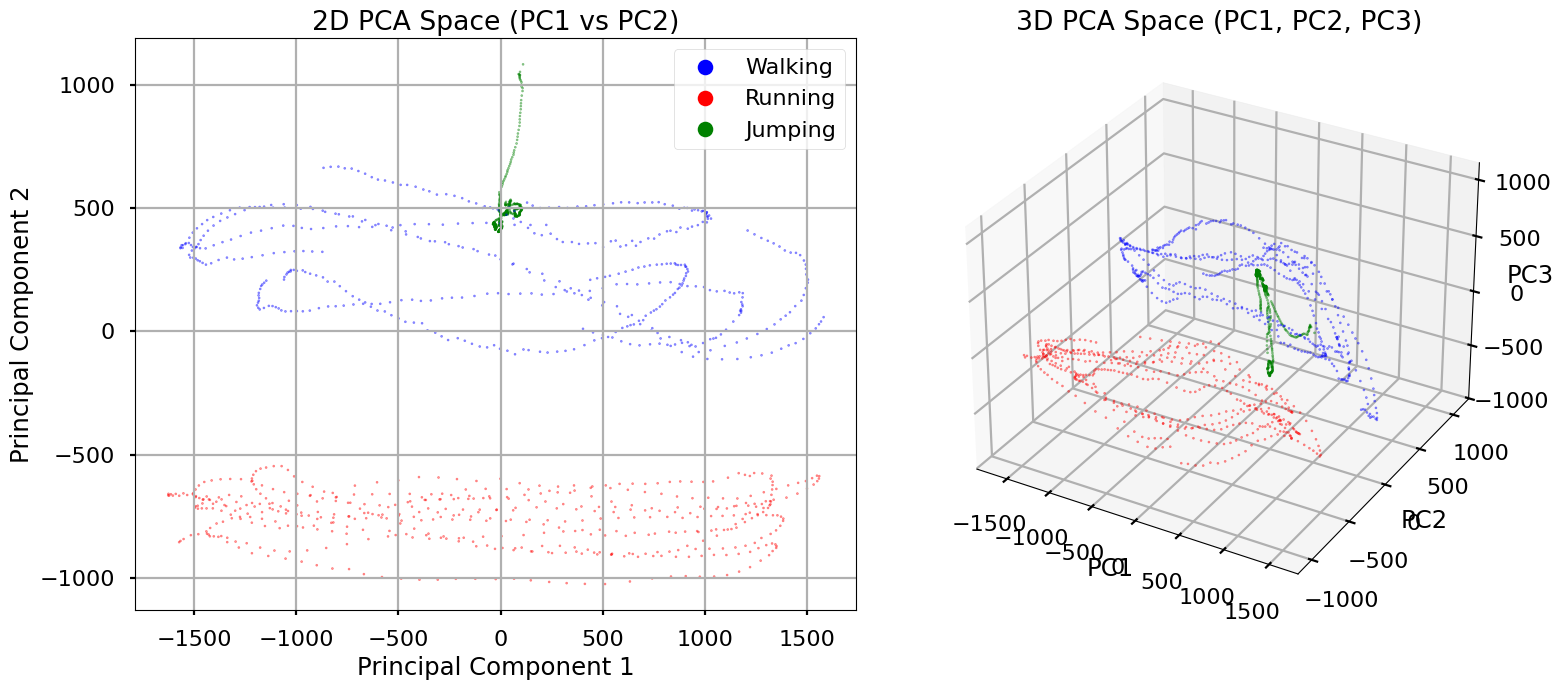

In [ ]:

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

# 1. Load data
folder = r"C:\Users\bluek\Downloads\drive-download-20260128T185252Z-3-001"
all_files = [f for f in os.listdir(folder) if f.endswith('.npy')]

X_list = []
labels = []
color_map = {'walking': 'blue', 'running': 'red', 'jumping': 'green'}

for f in sorted(all_files):
    data = np.load(os.path.join(folder, f))
    if len(data.shape) == 3:
        data = data.reshape(data.shape[0] * data.shape[1], -1)
    
    X_list.append(data)
    
    move_type = 'unknown'
    if 'walking' in f.lower(): move_type = 'walking'
    elif 'running' in f.lower(): move_type = 'running'
    elif 'jumping' in f.lower(): move_type = 'jumping'
    labels.extend([color_map.get(move_type, 'black')] * data.shape[1])

X_train = np.hstack(X_list)
labels = np.array(labels)

# 2. SVD and Projection
X_mean = np.mean(X_train, axis=1, keepdims=True)
X_centered = X_train - X_mean
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)


projections = U.T @ X_centered

# 3. Visualization
fig = plt.figure(figsize=(16, 7))

# 2D Plot (PC1, PC2)
ax1 = fig.add_subplot(121)
ax1.scatter(projections[0, :], projections[1, :], c=labels, s=2, alpha=0.4)
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.set_title('2D PCA Space (PC1 vs PC2)')
ax1.grid(True)

# 3D Plot (PC1, PC2, PC3)
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(projections[0, :], projections[1, :], projections[2, :], c=labels, s=2, alpha=0.4)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('3D PCA Space (PC1, PC2, PC3)')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='Walking', markerfacecolor='blue'),
                   Line2D([0], [0], marker='o', color='w', label='Running', markerfacecolor='red'),
                   Line2D([0], [0], marker='o', color='w', label='Jumping', markerfacecolor='green')]
ax1.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# 1. Establish Ground Truth Labels
class_mapping = {'walking': 0, 'jumping': 1, 'running': 2}
gt_labels = []

for f in sorted(all_files):
    data = np.load(os.path.join(folder, f))
    num_frames = data.shape[-1]
    
    move_type = 'unknown'
    for key in class_mapping.keys():
        if key in f.lower():
            move_type = key
            break
            
    label_idx = class_mapping.get(move_type, -1)
    gt_labels.extend([label_idx] * num_frames)

gt_labels = np.array(gt_labels)

# 2. Define the PCA subspace (k-modes)
k = 3
X_k_space = projections[:k, :].T 

# 3. Compute Centroids for each movement
centroids = {}
for move_name, label_idx in class_mapping.items():
    class_data = X_k_space[gt_labels == label_idx]
    
    if len(class_data) > 0:
        centroids[move_name] = np.mean(class_data, axis=0)
        print(f"Centroid for {move_name.capitalize()}: {centroids[move_name]}")

Centroid for Walking: [ 36.88211143 253.35282541 175.91202104]
Centroid for Jumping: [ 23.88986635 499.36826149 -72.5000755 ]
Centroid for Running: [ -60.77197779 -752.7210869  -103.41194553]


k =  1 | Accuracy: 50.73%
k =  2 | Accuracy: 88.13%
k =  3 | Accuracy: 75.60%
k =  5 | Accuracy: 75.07%
k = 10 | Accuracy: 88.80%
k = 20 | Accuracy: 91.07%


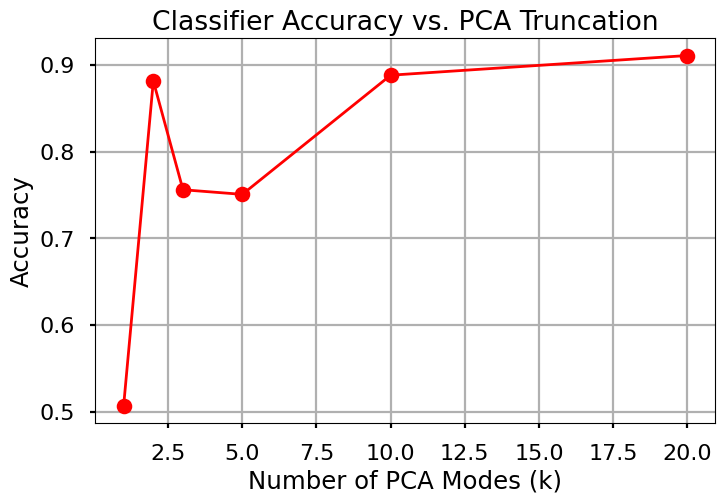

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

k_values = [1, 2, 3, 5, 10, 20]
accuracy_results = []

idx_to_class = {v: k for k, v in class_mapping.items()}

for k in k_values:
    # 1. Truncate PCA space to k modes
    X_k = projections[:k, :].T  # Shape: (Total_Frames, k)
    
    # 2. Re-compute centroids for this specific k-space
    current_centroids = []
    for i in range(len(class_mapping)):
        class_data = X_k[gt_labels == i]
        current_centroids.append(np.mean(class_data, axis=0))
    current_centroids = np.array(current_centroids) # Shape: (3, k)
    
    # 3. Classify each sample based on minimal Euclidean distance
    trained_labels = []
    for frame in X_k:
        distances = np.linalg.norm(current_centroids - frame, axis=1)
        trained_labels.append(np.argmin(distances))
    
    # 4. Compute Accuracy
    acc = accuracy_score(gt_labels, trained_labels)
    accuracy_results.append(acc)
    print(f"k = {k:2d} | Accuracy: {acc*100:.2f}%")

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_results, 'ro-', linewidth=2)
plt.xlabel('Number of PCA Modes (k)')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracy vs. PCA Truncation')
plt.grid(True)
plt.show()

k= 1 | Train Acc: 0.51 | Test Acc: 0.49
k= 2 | Train Acc: 0.88 | Test Acc: 0.98
k= 3 | Train Acc: 0.76 | Test Acc: 0.92
k= 5 | Train Acc: 0.75 | Test Acc: 0.92
k=10 | Train Acc: 0.89 | Test Acc: 0.94
k=20 | Train Acc: 0.91 | Test Acc: 0.95


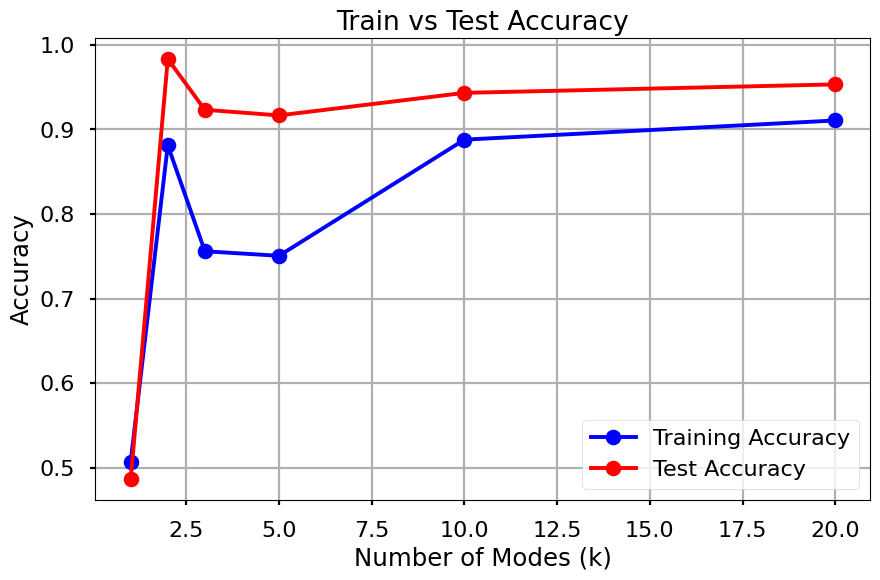

In [ ]:
import numpy as np
import os
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Setup Test Data (Update this path to your test folder)
test_folder = r"c:\Users\bluek\Downloads\drive-download-20260128T194607Z-3-001"
test_files = [f for f in os.listdir(test_folder) if f.endswith('.npy')]

X_test_list = []
test_gt_labels = []

# 2. Load Test Samples and Assign Ground Truth
for f in sorted(test_files):
    data = np.load(os.path.join(test_folder, f))
    if len(data.shape) == 3:
        data = data.reshape(data.shape[0] * data.shape[1], -1)
    
    X_test_list.append(data)
    
    move_type = 'unknown'
    if 'walking' in f.lower(): move_type = 0
    elif 'jumping' in f.lower(): move_type = 1
    elif 'running' in f.lower(): move_type = 2
    test_gt_labels.extend([move_type] * data.shape[1])

X_test_all = np.hstack(X_test_list)
test_gt_labels = np.array(test_gt_labels)

# 3. Preprocess Test Data 
X_test_centered = X_test_all - X_mean 
test_projections = U.T @ X_test_centered 

# 4. Run Test for various k
k_values = [1, 2, 3, 5, 10, 20]
test_acc_results = []
train_acc_results = []

for k in k_values:
    X_train_k = projections[:k, :].T
    train_centroids = np.array([np.mean(X_train_k[gt_labels == i], axis=0) for i in range(3)])
    
    X_test_k = test_projections[:k, :].T
    
    test_predictions = []
    for frame in X_test_k:
        dist = np.linalg.norm(train_centroids - frame, axis=1)
        test_predictions.append(np.argmin(dist))
    
    train_predictions = []
    for frame in X_train_k:
        dist = np.linalg.norm(train_centroids - frame, axis=1)
        train_predictions.append(np.argmin(dist))
        
    test_acc_results.append(accuracy_score(test_gt_labels, test_predictions))
    train_acc_results.append(accuracy_score(gt_labels, train_predictions))
    
    print(f"k={k:2d} | Train Acc: {train_acc_results[-1]:.2f} | Test Acc: {test_acc_results[-1]:.2f}")

# 5. Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_acc_results, 'bo-', label='Training Accuracy')
plt.plot(k_values, test_acc_results, 'ro-', label='Test Accuracy')
plt.xlabel('Number of Modes (k)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()